## Hypothesis: Does NASA's Budget Follow the Solar Cycle?

#### Test Statistic: Given a correlation coefficient between relative changes in NASA's budget and relative changes in solar activity, find its difference from the correlation between relative changes in the total budget of all other departments and the same relative changes in solar activity.
Expressed mathematically,

ρ( ΔSunspots  /  Sunspots  ,  ΔBudget_NASA  /  Budget_NASA)  -  ρ(ΔSunspots  /  Sunspots  ,  ΔBudget_Other  /  Budget_Other) 


#### Null: There is no difference in correlation of budget and solar activity between NASA and other departments.

#### Alternative: NASA's budget is more positively correlated with solar activity than the total budget of all other departments.


## Libraries & Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Data Loading

These datasets are needed to track changes in federal funding, internal allocations within NASA, and solar activity via observations of sunspots.

In [2]:
# Yearly appropriations for NASA compared to all other organizations
fed_budgets_raw = pd.read_csv("data/federal_budgets.csv")

# Yearly allocations to the constituent divisions of NASA's Science Directorate
division_budgets_raw = pd.read_csv("data/nasa_division_budgets.csv")

# Mean cont of sunspots per month
sunspots_raw = pd.read_json("data/sunspot_records.json")

# Date limits of each solar cycle
solar_cycle_raw = pd.DataFrame({
    'cycle_num' : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25],
    'start_date' : 	["1755-02", "1766-06", "1775-06", "1784-09", "1798-04", "1810-07",
                     "1823-05", "1833-11", "1843-07", "1855-12", "1867-03", "1878-12",
                     "1890-03", "1902-01", "1913-07", "1923-08", "1933-09", "1944-02",
                     "1954-04", "1964-10", "1976-03", "1986-09", "1996-08", "2008-12", "2019-12"],
    'end_date' : ["1766-06", "1775-06", "1784-09", "1798-04", "1810-07",
                  "1823-05", "1833-11", "1843-07", "1855-12", "1867-03", "1878-12",
                  "1890-03", "1902-01", "1913-07", "1923-08", "1933-09", "1944-02",
                  "1954-04", "1964-10", "1976-03", "1986-09", "1996-08", "2008-12", "2019-12", "2030-06"],
    'expected_start' : ["1755-02", "1766-02", "1777-02", "1788-02", "1799-02", "1810-02", "1821-02", "1832-02",
                        "1843-02", "1854-02", "1865-02", "1876-02", "1887-02", "1898-02", "1909-02", "1920-02",
                        "1931-02", "1942-02", "1953-02", "1964-02", "1975-02", "1986-02", "1997-02", "2008-02","2019-02"],
    'expected_end' : ["1766-02", "1777-02", "1788-02", "1799-02", "1810-02", "1821-02", "1832-02",
                      "1843-02", "1854-02", "1865-02", "1876-02", "1887-02", "1898-02", "1909-02", "1920-02",
                      "1931-02", "1942-02", "1953-02", "1964-02", "1975-02", "1986-02", "1997-02", "2008-02","2019-02", "2030-02"]
})



## Cleaning & Transformations

### Transformation Helper Functions

In [3]:
# Given a date, returns which observed solar cycle that date is in
def getObservedCycle(date, df) :
    
    # Check for which solar cycle a date falls in
    mask = (df['start_date'] <= date) & (date < df['end_date'])
    match = df[mask]
    
    if not match.empty:
        return match.iloc[0]['cycle_num'] 
    
    # Either the date is in the future, or it's before the first official solar cycle in 1755
    return np.nan


# Given a date, returns the expected solar cycle assuming a consistent 11-year cycle
# (Maybe redundant to have a slightly tweaked copy of getObservedCycle, but I think having separate funcs improves legibility)
def getExpectedCycle(date, df) :

    mask = (df['expected_start'] <= date) & (date < df['expected_end'])
    match = df[mask]
    
    if not match.empty:
        return match.iloc[0]['cycle_num'] 
    
    # Either the date is in the future, or it's before the first official solar cycle in 1755
    return np.nan


### Solar Cycle Dataset

In [4]:
solar_cycle = solar_cycle_raw.copy()

# Cast as datetime
solar_cycle['start_date'] = pd.to_datetime(solar_cycle['start_date'])
solar_cycle['end_date'] = pd.to_datetime(solar_cycle['end_date'])
solar_cycle['expected_start'] = pd.to_datetime(solar_cycle['expected_start'])
solar_cycle['expected_end'] = pd.to_datetime(solar_cycle['expected_end'])


### Sunspots Dataset

In [5]:
sunspots = sunspots_raw.copy()

# Reformat columns
sunspots = sunspots.drop(labels=['smoothed_ssn', 'observed_swpc_ssn', 'smoothed_swpc_ssn', 'f10.7', 'smoothed_f10.7'], axis=1)
sunspots = sunspots.rename(columns={'time-tag' : 'date'})

# Cast as datetime
sunspots['date'] = pd.to_datetime(sunspots['date'])

# Set solar Observed and Expected cycle numbers
sunspots['cycle_obsv'] = sunspots['date'].apply(lambda x: getObservedCycle(x, solar_cycle)).astype('Int64')
sunspots['cycle_expc'] = sunspots['date'].apply(lambda x: getExpectedCycle(x, solar_cycle)).astype('Int64')


# Drop rows from before the first recorded solar cycle
sunspots = sunspots.dropna().reset_index(drop=True)

# Assign rows a government fiscal year 
# (runs from October of the preceding calendar year through September of the current calendar year)
# Example: December 2025 is in US Fiscal Year 2026
sunspots['gov_fiscal_year'] = sunspots['date'].dt.to_period('Y-SEP')
sunspots['gov_fiscal_year'] = sunspots['gov_fiscal_year'].apply(lambda x : x.year).astype('int64')

# An 11-year solar cycle is supposed to start and end in periods of low solar activity
# Assign 'high' and 'low' flags accordingly
sunspots['activity_expc'] = sunspots.groupby('cycle_expc')['date'].transform(
    lambda x: pd.cut(x, bins=4, ordered=False, labels=['low', 'high', 'high', 'low']))



### Federal Budgets Dataset

In [6]:

fed_budgets = fed_budgets_raw.copy()

# Cast budget data as numeric
fed_budgets['budget_nominal'] = fed_budgets['budget_nominal'].str.replace(',', '')
fed_budgets['budget_nominal'] = pd.to_numeric(fed_budgets['budget_nominal']).astype('float64')
fed_budgets['budget_real'] = fed_budgets['budget_real'].str.replace(',', '')
fed_budgets['budget_real'] = pd.to_numeric(fed_budgets['budget_real']).astype('float64')

# Create datetime attributes
fed_budgets['gfy_start'] = pd.to_datetime(fed_budgets['gov_fiscal_year'], format='%Y') - pd.DateOffset(months=3)
fed_budgets['gfy_end'] = fed_budgets['gfy_start'] + pd.DateOffset(months=12)

# Merge sunspot data onto fed_budgets
sunspots_fed = sunspots.copy()
sunspots_fed = sunspots_fed.groupby('gov_fiscal_year')['ssn'].mean() # Mean sunspots in fiscal year
fed_budgets = pd.merge(fed_budgets, sunspots_fed, on='gov_fiscal_year')

# Get the % change in ssn over the prior row
fed_budgets['ssn_delta'] = fed_budgets['ssn'] / fed_budgets['ssn'].shift(1) - 1
fed_budgets['ssn_delta'] = fed_budgets['ssn_delta'].fillna(0)

# The Space Race years are outliers, so they should be dropped
fed_budgets = fed_budgets.drop(fed_budgets.loc[fed_budgets['gov_fiscal_year'] < 1972].index).reset_index(drop=True)


### Science Divisions Budgets Dataset

In [7]:

division_budgets = division_budgets_raw.copy()

# Cast budget data as numeric
division_budgets['budget_nominal'] = division_budgets['budget_nominal'].str.replace(',', '')
division_budgets['budget_nominal'] = pd.to_numeric(division_budgets['budget_nominal']).astype('float64')
division_budgets['budget_real'] = division_budgets['budget_real'].str.replace(',', '')
division_budgets['budget_real'] = pd.to_numeric(division_budgets['budget_real']).astype('float64')

# Create datetime attributes
division_budgets['gfy_start'] = pd.to_datetime(division_budgets['gov_fiscal_year'], format='%Y') - pd.DateOffset(months=3)
division_budgets['gfy_end'] = division_budgets['gfy_start'] + pd.DateOffset(months=12)

# Merge sunspot data onto division_budgets
sunspots_div = sunspots.copy()
sunspots_div = sunspots_div.groupby('gov_fiscal_year')['ssn'].mean() # Mean sunspots in fiscal year
division_budgets = pd.merge(division_budgets, sunspots_div, on='gov_fiscal_year')

# Get the % change in ssn over the prior row
division_budgets['ssn_delta'] = division_budgets['ssn'] / division_budgets['ssn'].shift(1) - 1
division_budgets['ssn_delta'] = division_budgets['ssn_delta'].fillna(0)

## Analysis

### Helper Functions

In [9]:
# Find the difference in Pearson correlation coefficients
def corrDiff(df) : 

    df_nasa = df.loc[df['departments_group'] == 'nasa']
    df_other = df.loc[df['departments_group'] == 'other']

    corr_nasa = stats.pearsonr(df_nasa['ssn_delta'], df_nasa['budget_real_yearly_delta'])
    corr_other = stats.pearsonr(df_other['ssn_delta'], df_other['budget_real_yearly_delta'])

    return corr_nasa[0] - corr_other[0]

### Permutation Test: Correlation Difference

If department makes no difference, then shuffling the department_group column won't yield any difference in correlation with solar activity. By simulating this shuffling many times, we can generate many different permutations of the sample statistic and use them to build a reference distribution.

In [10]:

obsv_diff = corrDiff(fed_budgets)
replicate_diffs = [] 
num_sim = 1000
replicate = fed_budgets.copy()

departments = replicate['departments_group'].tolist()

for _ in range(num_sim) : 

    np.random.shuffle(departments) # Generate a random permutation of NASA and Other
    replicate['departments_group'] = departments

    # Get the test statistic for the permutation
    replicate_diffs.append(corrDiff(replicate))

replicate_diffs = pd.DataFrame({'replicate_diff':replicate_diffs})


Now we can plot the reference distribution and compare it to the observed effect.

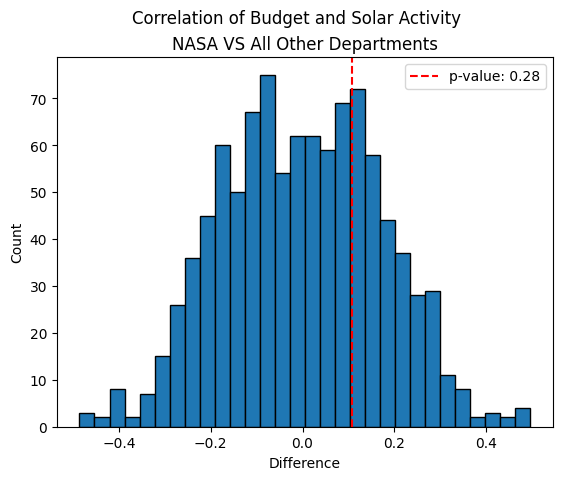

In [11]:
plt.hist(replicate_diffs, bins=30, edgecolor='black')
plt.xlabel("Difference")
plt.ylabel("Count")
plt.suptitle("Correlation of Budget and Solar Activity")
plt.title("NASA VS All Other Departments")

# Calculate proportion of simulations greater than the observed
extreme_count = (replicate_diffs['replicate_diff'] >= obsv_diff).sum()
p_val = extreme_count / len(replicate_diffs)

# Plot observed difference
ax = plt.gca()
ymax = ax.get_ylim()[1]
xmin, xmax = ax.get_xlim()
offset = 0.2 * (xmax - xmin)  
plt.axvline(x=obsv_diff, color="red", linestyle="--", label=f"p-value: {p_val:.2}")
plt.legend()

plt.savefig("result_figures/nasa_sunspots_corr_significance.jpg")

plt.show()

### Bootstrap Uncertainty: Correlation Coefficient of NASA's Budget and Solar Activity

We're going to take a deeper look at this correlation statistic. The Central Limit Theorem doesn't apply here because there are an infinite number of potential values for the Pearson correlation coefficient, transgressing the "finite variance" rule of the CLT.

We're looking for the level of uncertainty regarding this correlation. To that end, we'll filter down fed_budgets to just the NASA rows, and bootstrap a reference distribution with 1000 simulations. Each run in the simulation samples all rows in nasa_budgets with replacement, generating a new correlation coefficient. The standard error for the distribution of these sample statistics forms the basis for our 95% confidence interval.

In [12]:

nasa_budgets = fed_budgets.loc[fed_budgets['departments_group'] == 'nasa'].reset_index(drop=True)
nasa_corr = stats.pearsonr(nasa_budgets['ssn'], nasa_budgets['budget_real'])[0]
nasa_boot = pd.DataFrame({'department' : ['NASA'], 'corr' : [nasa_corr]})

nasa_boot['boot_se'] = pd.NA
nasa_boot['ci_lower'] = pd.NA
nasa_boot['ci_upper'] = pd.NA

n_sim = 1_000
samples = []


for _ in range(n_sim) :
  
  sample = nasa_boot.sample(n=len(nasa_boot),replace=True)
  samples.append(stats.pearsonr(nasa_budgets['ssn'], nasa_budgets['budget_real'])[0])

boot_se = np.std(samples)
nasa_boot['boot_se'] = boot_se

# 95% CI is equivalent to a magnitude of two standard errors
nasa_boot['ci_lower'] = nasa_boot['corr'] - 2 * boot_se
nasa_boot['ci_upper'] = nasa_boot['corr'] + 2 * boot_se

Now we can print our results and visualize.

  department      corr       boot_se  ci_lower  ci_upper
0       NASA  0.006153  8.673617e-19  0.006153  0.006153


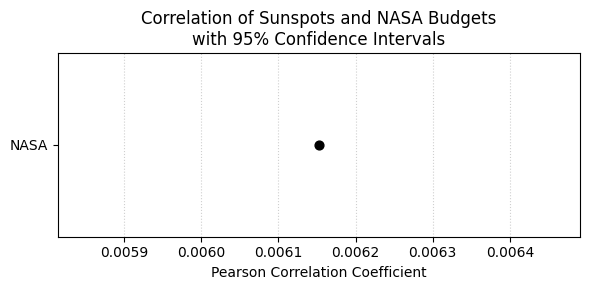

In [13]:
print(nasa_boot)

plt.figure(figsize=(6, 3))

# CI lines
plt.hlines(
    y=nasa_boot['department'],
    xmin=nasa_boot['corr'] - 2 * nasa_boot['boot_se'],
    xmax=nasa_boot['corr'] + 2 * nasa_boot['boot_se'],
    color='lightgray',
    lw=3,
    zorder=1
)

# Point estimates
plt.scatter(
    nasa_boot['corr'],
    nasa_boot['department'],
    s=40,
    color='black',
    zorder=2
)

plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('')
plt.title('Correlation of Sunspots and NASA Budgets\nwith 95% Confidence Intervals')
#plt.xlim(4, 5)
plt.grid(axis='x', linestyle=':', alpha=0.6, zorder=0)
plt.tight_layout()

plt.savefig("result_figures/CorrelationCI.jpg")
plt.show()

## Results

We were able to analyze the connection between solar activity and research funding by considering historical sunspot counts (the oldest measure of solar activity) and their potential connection to changes in NASA funding, the reasoning being that Presidential Administrations and Congressional Committees would be motivated by security or infrastructural concerns to push for more funding during times when the Sun presents a clear risk of disaster to modern society. The results do not point to such a conclusion.

With a results showing a p-value of only 0.28, Our permutation test failed to reject the null hypothesis that there is no difference in the correlation between NASA's budget changes and sunspots, and that for the rest of the US government. 

On its own, NASA's budget has very little correlation with sunspots, with a coefficient of just 0.0061, and a standard error of less than one quintillionth.

Within the framework of this investigation, there's a great deal of confidence that solar activity has no impact whatsoever on the appropriations granted by the federal government. However, that isn't the only relevant question to consider. Investigating internal NASA allocations might yeild interesting insights; it stands to reason that a decision-making body more familiar with NASA's operations would be more deliberate in distributing its funds, potentially with an eye towards solar activity. 